# CLIP + SAM

In [82]:
# install necessary modules
import sys

!{sys.executable} -m pip install torch opencv-python Pillow
!{sys.executable} -m pip install git+https://github.com/openai/CLIP.git
!{sys.executable} -m pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/openai/CLIP.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-e6bi3kx_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-e6bi3kx_
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-74dics0c
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-74dics0c
  Resolved https://github.com/facebookresearch/segment-anything.git to commit 6fdee8f2727f4506cfbbe553e23b895e27956588
  Preparing metadata (setup.py) ... done


In [83]:
import cv2
from segment_anything import build_sam, SamAutomaticMaskGenerator
from PIL import Image, ImageDraw
import clip
import torch
import numpy as np

In [84]:
# load SAM

sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

#sam_checkpoint = "checkpoints/sam_vit_b_01ec64.pth"
sam_checkpoint = "checkpoints/sam_vit_l_0b3195.pth"
model_type = "vit_l"

#default
device = "cpu"

#NVIDIA
#device = "cuda"

#M1 chips
#device = "mps"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

In [101]:
image_path = "images/190605173640_01.png"

In [102]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image)

In [85]:
def convert_box_xywh_to_xyxy(box):
    x1 = box[0]
    y1 = box[1]
    x2 = box[0] + box[2]
    y2 = box[1] + box[3]
    return [x1, y1, x2, y2]

In [86]:
def segment_image(image, segmentation_mask):
    image_array = np.array(image)
    
    segmented_image_array = np.zeros_like(image_array)
    segmented_image_array[segmentation_mask] = image_array[segmentation_mask]
    segmented_image = Image.fromarray(segmented_image_array)
    
    black_image = Image.new("RGB", image.size, (0, 0, 0))
    
    transparency_mask = np.zeros_like(segmentation_mask, dtype=np.uint8)
    transparency_mask[segmentation_mask] = 255
    transparency_mask_image = Image.fromarray(transparency_mask, mode='L')
    
    black_image.paste(segmented_image, mask=transparency_mask_image)
    return black_image

In [103]:
# Cut out all masks

import matplotlib.pyplot as plt

image = Image.open(image_path)
cropped_boxes = []

for mask in masks:
    
    # Access the 'segmentation' key to get the mask
    segmentation_mask = mask['segmentation']
    
    # Display the segmentation mask
    #plt.figure(figsize=(20, 20))
    #plt.imshow(segmentation_mask, cmap='gray')
    #plt.axis('off')
    #plt.show()
    cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))

In [13]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

100%|████████████████████████████████████████| 338M/338M [06:57<00:00, 847kiB/s]


In [99]:
@torch.no_grad()
def retriev(elements: list[Image.Image], search_text: str) -> int:
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    tokenized_text = clip.tokenize([search_text]).to(device)
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    text_features = model.encode_text(tokenized_text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    probs = 100. * image_features @ text_features.T
    return probs[:, 0].softmax(dim=0)

In [15]:
def get_indices_of_values_above_threshold(values, threshold):
    return [i for i, v in enumerate(values) if v > threshold]

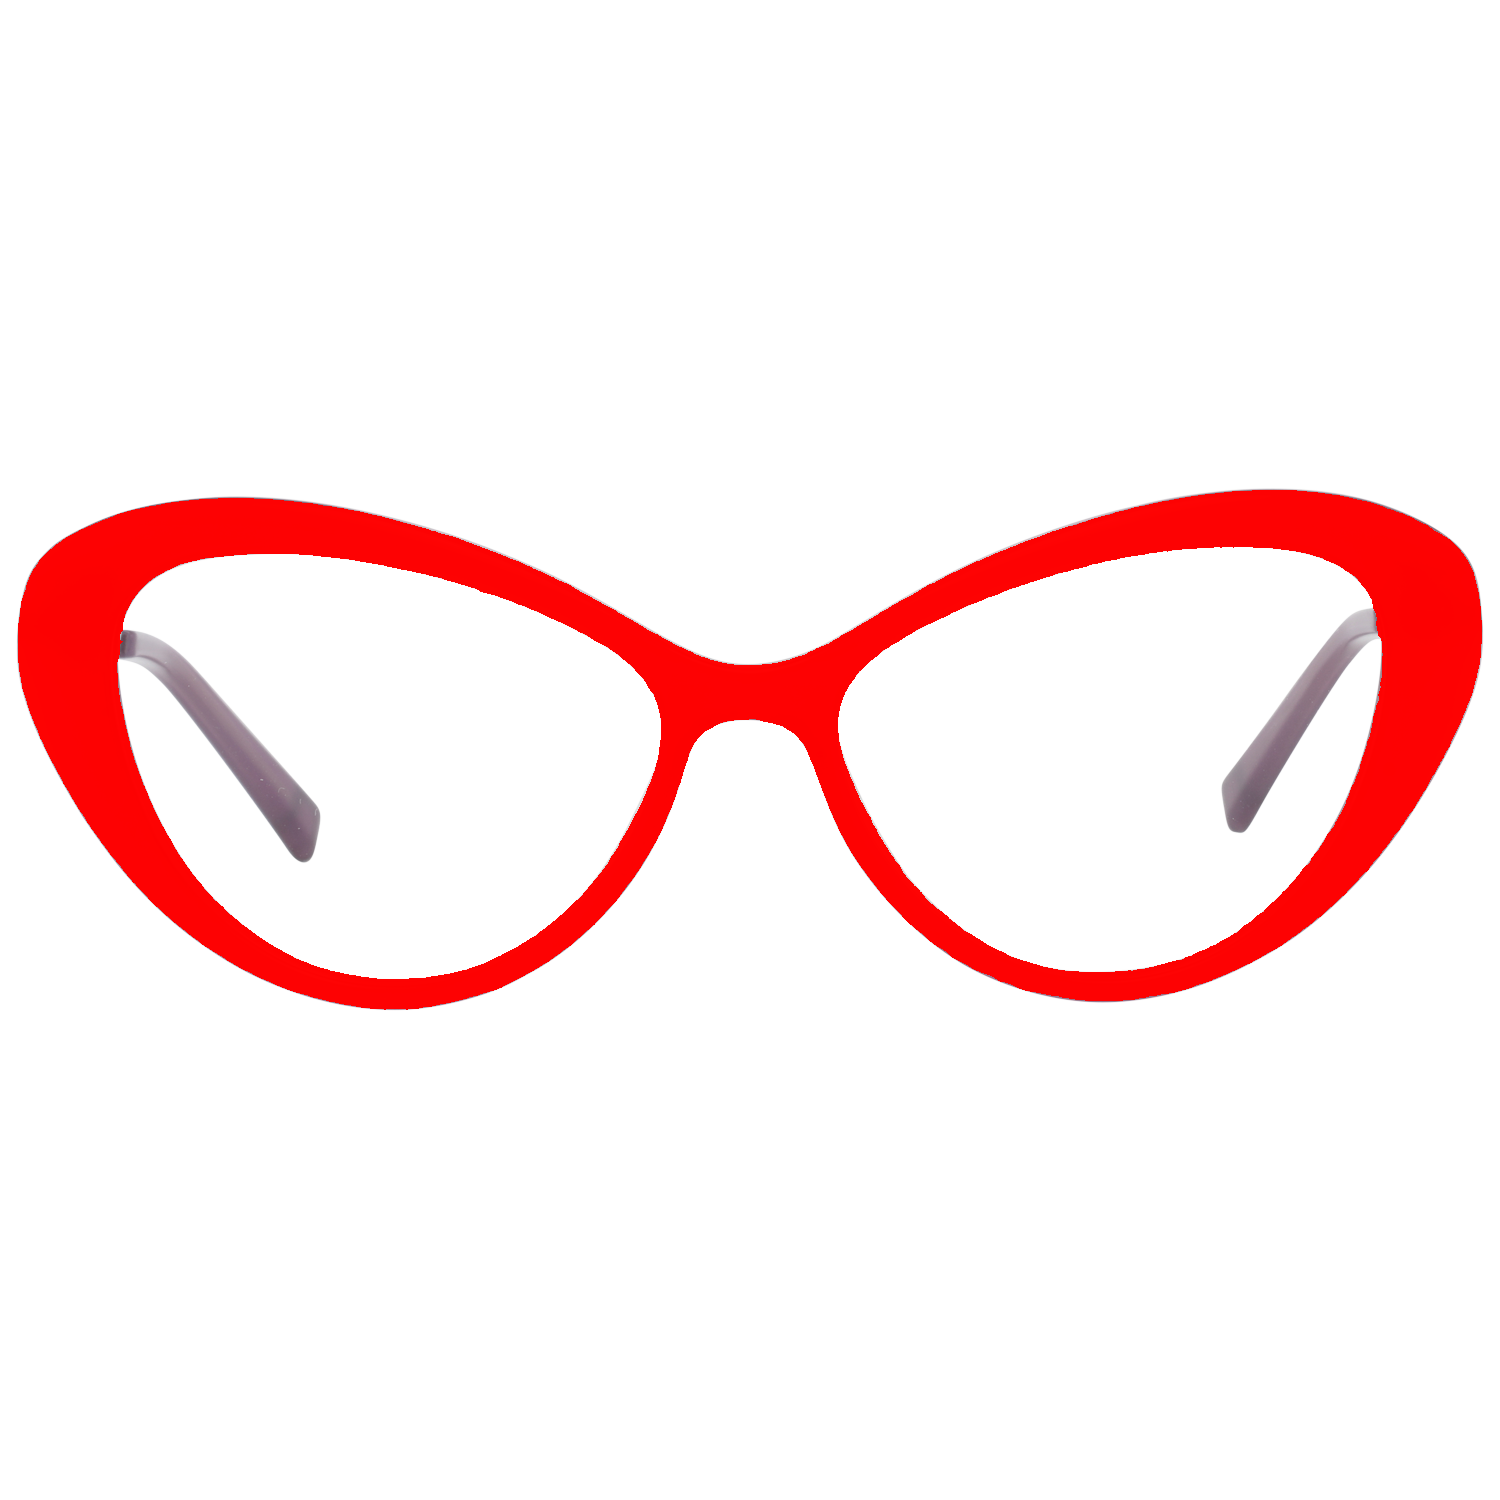

In [104]:
scores = retriev(cropped_boxes, "eyeframe")
indices = get_indices_of_values_above_threshold(scores, 0.05)

segmentation_masks = []

for seg_idx in indices:
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    segmentation_masks.append(segmentation_mask_image)
    

original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', image.size, (0, 0, 0, 0))
overlay_color = (255, 0, 0, 250)

draw = ImageDraw.Draw(overlay_image)
for segmentation_mask_image in segmentation_masks:
    draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color)

result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image

### Bad example

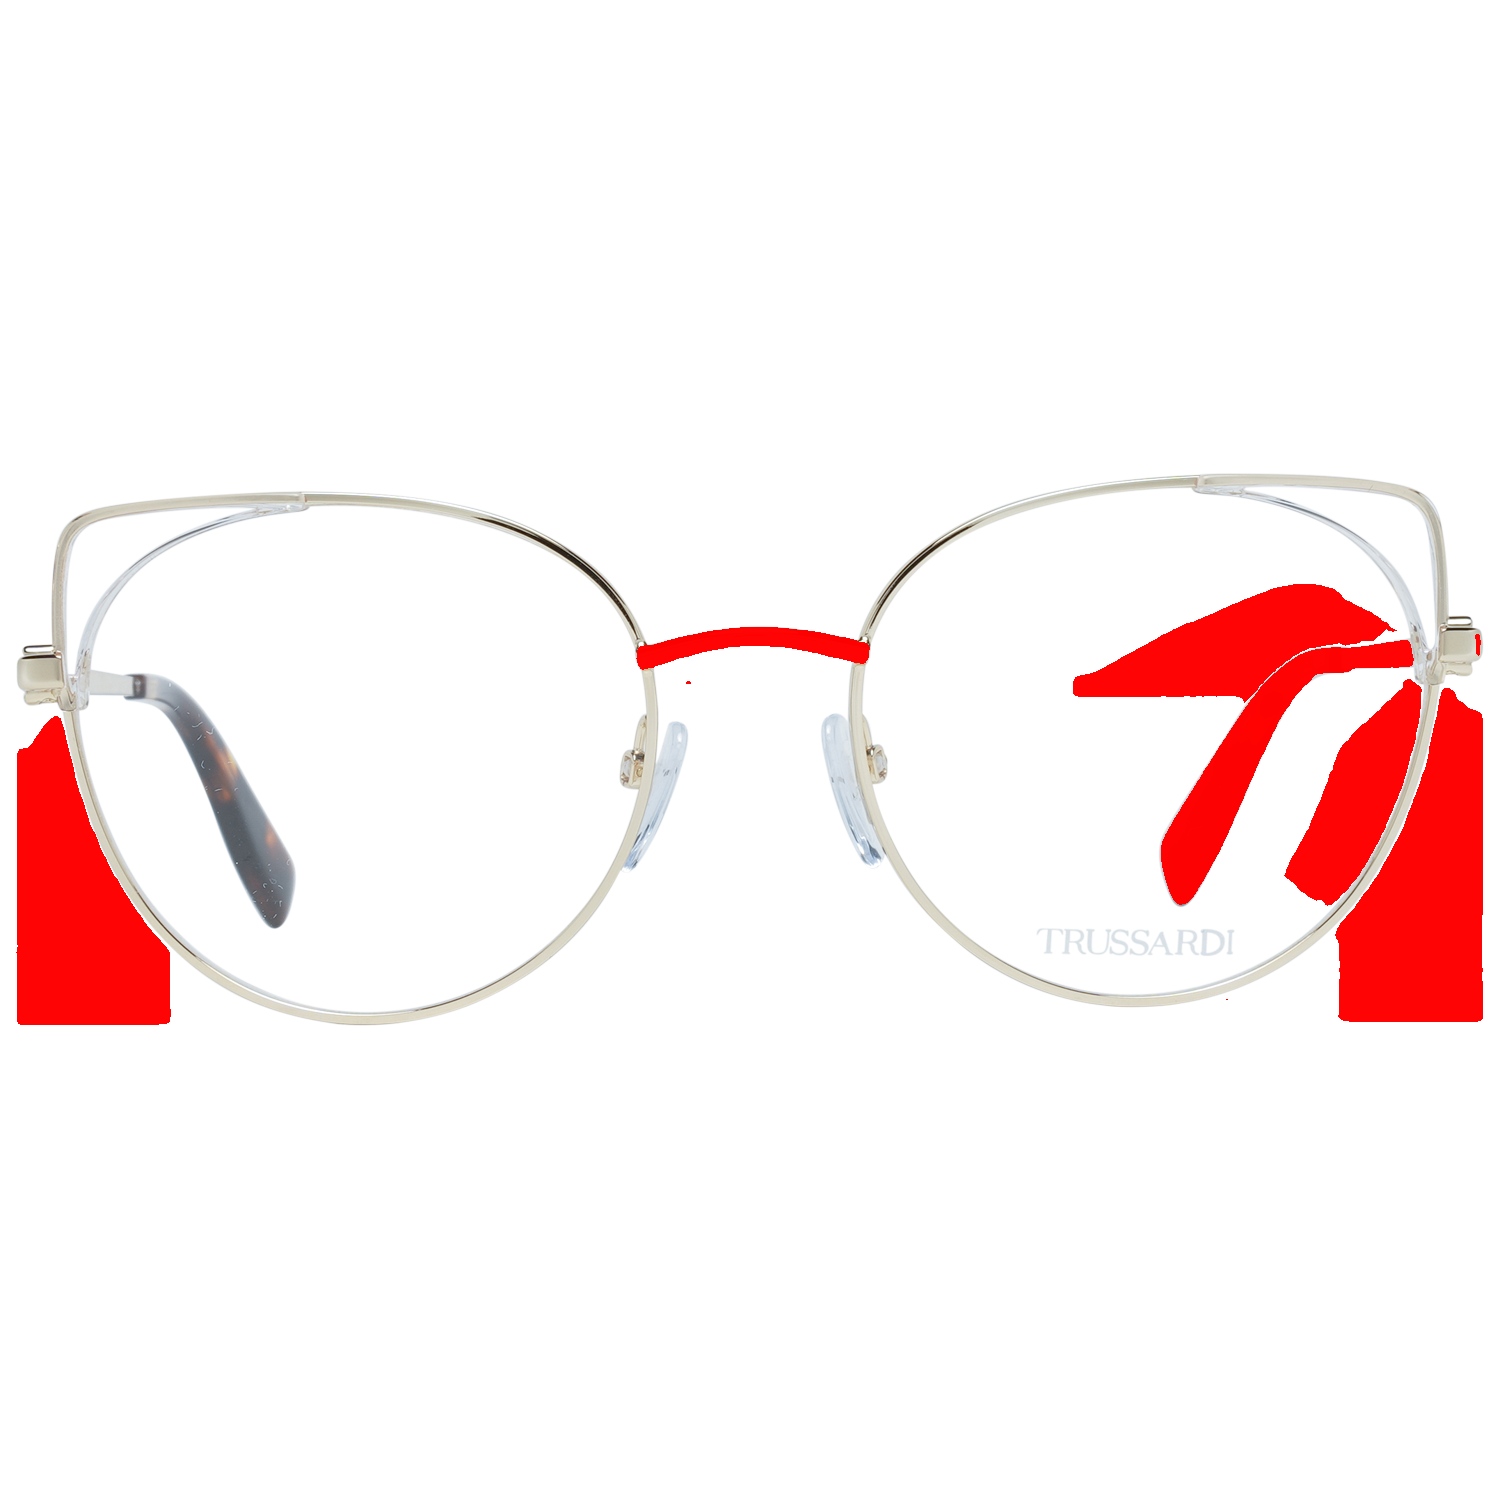